In [26]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split


sys.path.insert(0, "/data/keeling/a/jdnied2/c/598/rs-embed/src")
sys.path.insert(0, "/data/keeling/a/jdnied2/c/598/rs-embed/")

from examples.utils_demo import (
    ee_initialize,
    iter_export_points,
    iter_model_vectors,
    load_one_preview_patch,
    point_key,
    point_row_index,
    resolve_preview_group_dirs,
    rings_from_geom_info,
    stretch_rgb,
)
from rs_embed import InputPrepSpec, OutputSpec, PointBuffer, TemporalSpec, export_batch

STATES = ["Minnesota", "South Dakota", "Kansas", 
          "Iowa", "Illinois", "Indiana", 
          "Missouri", "Wisconsin", "Kentucky"]

# Replace your path here
H_CSV = "/data/keeling/a/jdnied2/c/598/rs-embed/dataverse_files/Global_CSV/spam2020V2r0_global_harvested_area/spam2020V2r0_global_H_TA.csv"
Y_CSV = "/data/keeling/a/jdnied2/c/598/rs-embed/dataverse_files/Global_CSV/spam2020V2r0_global_yield/spam2020V2r0_global_Y_TA.csv"
EXPORT_ROOT = Path(os.getenv("DEMO_EXPORT_DIR", "./exports_tile")).expanduser()

SPAM_CROP_COL = os.getenv("SPAM_CROP_COL", "MAIZ_A").upper()
COUNTRY_CODE = os.getenv("SPAM_COUNTRY_CODE", "US").upper()
# LABEL_YEAR = int(os.getenv("SPAM_LABEL_YEAR", "2020"))
MIN_AREA_HA = float(os.getenv("MAIZ_AREA_MIN_HA", "2500"))
# MIN_AREA_HA = float(os.getenv("MAIZ_AREA_MIN_HA", "1000"))

BUFFER_M = int(os.getenv("BUFFER_M", "2000"))

# Select model as needed here
MODEL_LIST = [
    "terrafm",
    "satvision",
    "agrifm",
    "satmae"
]


EMBED_START = os.getenv("EMBED_START", "2019-06-01")
EMBED_END = os.getenv("EMBED_END", "2019-08-31")
TEMPORAL = TemporalSpec.range(EMBED_START, EMBED_END)

TEST_SIZE = float(os.getenv("REG_TEST_SIZE", "0.25"))
MIN_SAMPLES = int(os.getenv("MIN_MODEL_SAMPLES", "30"))

EE_PROJECT = os.getenv("EE_PROJECT")
EE_PROJECT = "cs-598-491115"
print(
    {
        "EXPORT_ROOT": str(EXPORT_ROOT),
        "MODEL_LIST": MODEL_LIST,
        # "LABEL_YEAR": LABEL_YEAR,
        "BUFFER_M": BUFFER_M,
        "TEMPORAL": [EMBED_START, EMBED_END],
    }
)

SAVE_INPUTS = bool(int(os.getenv("SAVE_INPUTS", "1")))

{'EXPORT_ROOT': 'exports_tile', 'MODEL_LIST': ['terrafm', 'satvision', 'agrifm', 'satmae'], 'BUFFER_M': 2000, 'TEMPORAL': ['2019-06-01', '2019-08-31']}


In [27]:
import ee
out = ee.Initialize(project="cs-598-491115") 
print(out)

None


In [28]:
# rings_from_geom_info(roi_geom.getInfo())

In [29]:
def rings_from_geom_info(geom_info: dict):
    gtype = geom_info.get("type")
    coords = geom_info.get("coordinates", [])

    if gtype == "Polygon":
        # coords[0] = exterior boundary; coords[1:] = holes
        return [np.asarray(coords[0], dtype=float)]

    if gtype == "MultiPolygon":
        return [
            np.asarray(poly[0], dtype=float)
            for poly in coords
            if poly and poly[0]
        ]

    if gtype == "LineString":
        return [np.asarray(coords, dtype=float)]

    if gtype == "MultiLineString":
        return [
            np.asarray(line, dtype=float)
            for line in coords
            if line
        ]

    if gtype == "GeometryCollection":
        rings = []
        for geom in geom_info.get("geometries", []):
            rings.extend(rings_from_geom_info(geom))
        return rings

    # Skip anything else instead of crashing
    return []

<h1> Plot SPAM Maize State Dist. </h1>

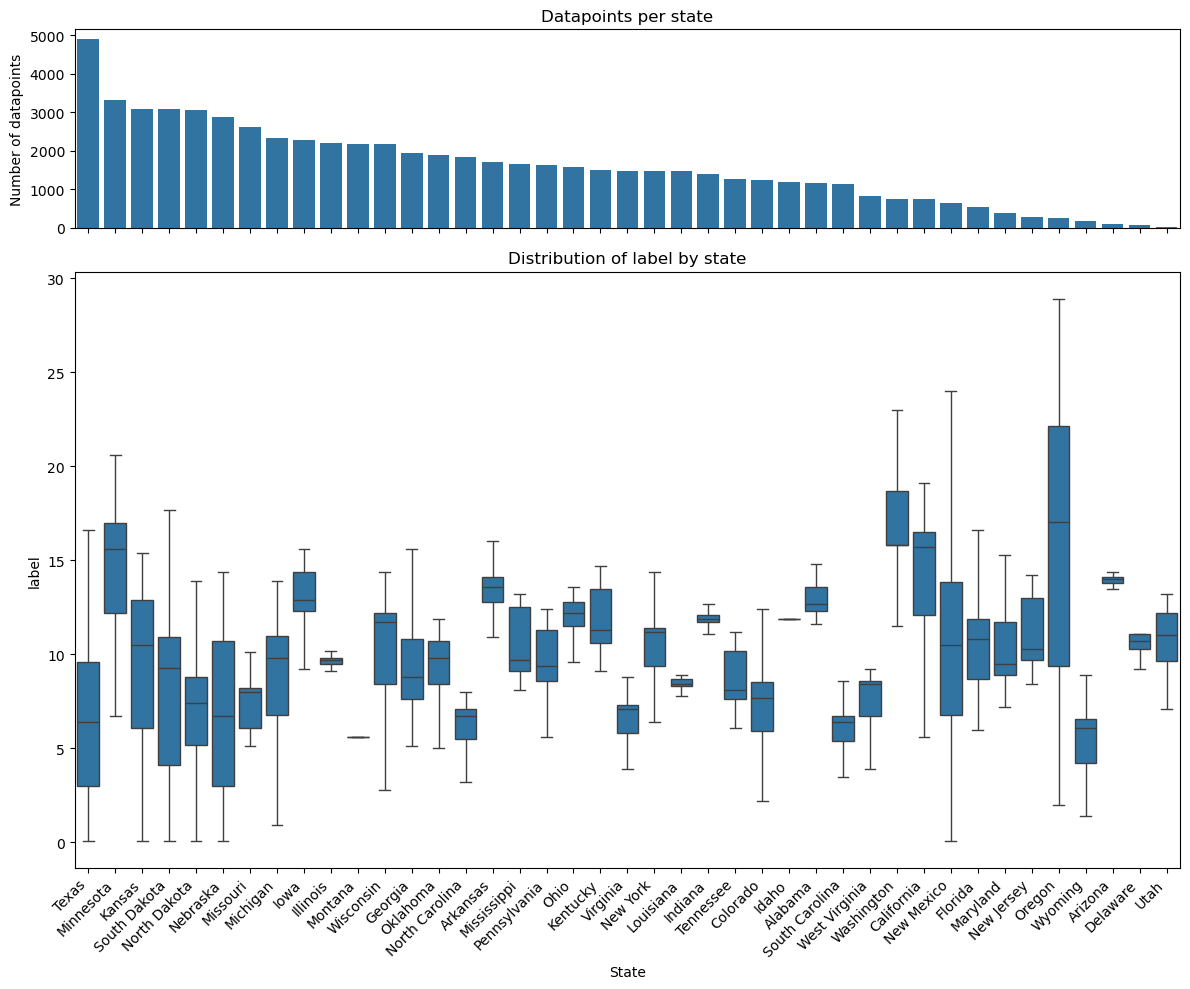

In [14]:
# No subsample - all data
csv_path  = H_CSV
value_name="maize_area_ha"
usecols = ["grid_code", "x", "y", "FIPS0", "ADM1_NAME", "year_data", SPAM_CROP_COL]
table = pd.read_csv(csv_path, usecols=usecols, encoding="utf-8-sig")
table = table.rename(columns={"x": "lon", "y": "lat", SPAM_CROP_COL: value_name})

table["grid_code"] = table["grid_code"].astype(str)
table["FIPS0"] = table["FIPS0"].astype(str).str.upper()
table["ADM1_NAME"] = table["ADM1_NAME"].astype(str)
table["year_data"] = table["year_data"].astype(str)
table[value_name] = pd.to_numeric(table[value_name], errors="coerce")

table_h = table[
    table["FIPS0"].eq(COUNTRY_CODE)
    # & table["year_data"].str.contains(str(LABEL_YEAR), na=False)
]


csv_path  = Y_CSV
value_name="label"
usecols = ["grid_code", "x", "y", "FIPS0", "ADM1_NAME", "year_data", SPAM_CROP_COL]
table = pd.read_csv(csv_path, usecols=usecols, encoding="utf-8-sig")
table = table.rename(columns={"x": "lon", "y": "lat", SPAM_CROP_COL: value_name})

table["grid_code"] = table["grid_code"].astype(str)
table["FIPS0"] = table["FIPS0"].astype(str).str.upper()
table["ADM1_NAME"] = table["ADM1_NAME"].astype(str)
table["year_data"] = table["year_data"].astype(str)
table[value_name] = pd.to_numeric(table[value_name], errors="coerce")

table_y = table[
    table["FIPS0"].eq(COUNTRY_CODE)
    # & table["year_data"].str.contains(str(LABEL_YEAR), na=False)
]
table_y = table_y[table_y["label"] > 0].drop_duplicates("grid_code")


table = None
table = (
        table_h.merge(table_y[["grid_code", "label"]], on="grid_code", how="inner")
        .sort_values(["lat", "lon"])
        .reset_index(drop=True)
    )

counts_per_state = (
    table
    .groupby("ADM1_NAME")
    .size()
    .reset_index(name="n_datapoints")
)

state_order = counts_per_state.sort_values(
    "n_datapoints", ascending=False
)["ADM1_NAME"]

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(
    2, 1,
    figsize=(12, 10),
    sharex=True,
    gridspec_kw={"height_ratios": [1, 3]}
)

# --- Top: counts per state ---
sns.barplot(
    data=counts_per_state,
    x="ADM1_NAME",
    y="n_datapoints",
    order=state_order,
    ax=axes[0]
)

axes[0].set_ylabel("Number of datapoints")
axes[0].set_title("Datapoints per state")

# --- Bottom: box + whisker ---
sns.boxplot(
    data=table,
    x="ADM1_NAME",
    y=value_name,
    order=state_order,
    ax=axes[1],
    showfliers=False  # cleaner; remove if you want outliers
)

axes[1].set_ylabel(value_name)
axes[1].set_xlabel("State")
axes[1].set_title(f"Distribution of {value_name} by state")

# Rotate labels
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

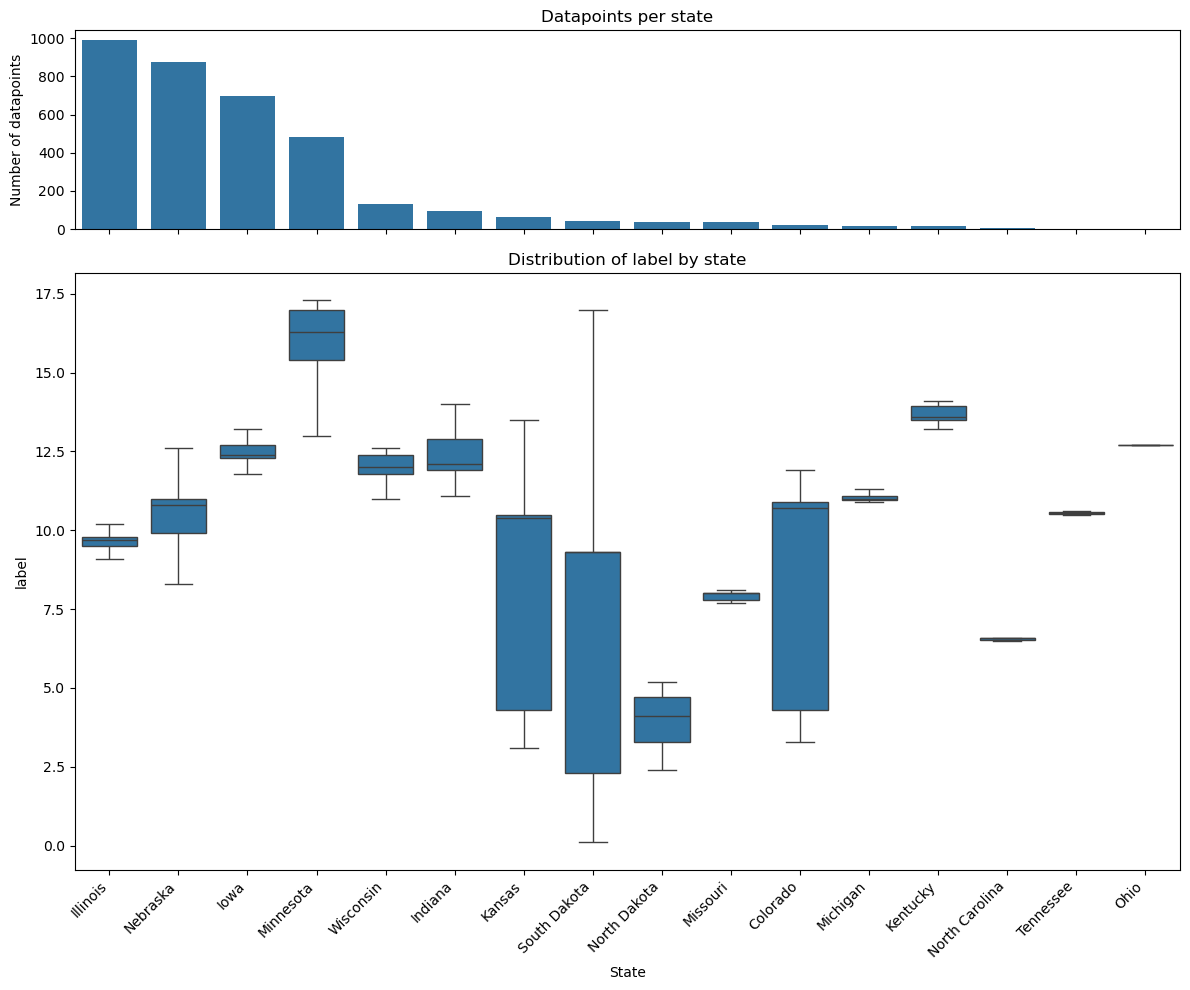

In [30]:
# For sample logic: I.e., filter by harvest ared of greated than 2.5 km
csv_path  = H_CSV
value_name="maize_area_ha"
usecols = ["grid_code", "x", "y", "FIPS0", "ADM1_NAME", "year_data", SPAM_CROP_COL]
table = pd.read_csv(csv_path, usecols=usecols, encoding="utf-8-sig")
table = table.rename(columns={"x": "lon", "y": "lat", SPAM_CROP_COL: value_name})

table["grid_code"] = table["grid_code"].astype(str)
table["FIPS0"] = table["FIPS0"].astype(str).str.upper()
table["ADM1_NAME"] = table["ADM1_NAME"].astype(str)
table["year_data"] = table["year_data"].astype(str)
table[value_name] = pd.to_numeric(table[value_name], errors="coerce")

table_h = table[
    table["FIPS0"].eq(COUNTRY_CODE)
    # & table["year_data"].str.contains(str(LABEL_YEAR), na=False)
]
table_h = table_h[table_h["maize_area_ha"] >= MIN_AREA_HA].drop_duplicates("grid_code")


csv_path  = Y_CSV
value_name="label"
usecols = ["grid_code", "x", "y", "FIPS0", "ADM1_NAME", "year_data", SPAM_CROP_COL]
table = pd.read_csv(csv_path, usecols=usecols, encoding="utf-8-sig")
table = table.rename(columns={"x": "lon", "y": "lat", SPAM_CROP_COL: value_name})

table["grid_code"] = table["grid_code"].astype(str)
table["FIPS0"] = table["FIPS0"].astype(str).str.upper()
table["ADM1_NAME"] = table["ADM1_NAME"].astype(str)
table["year_data"] = table["year_data"].astype(str)
table[value_name] = pd.to_numeric(table[value_name], errors="coerce")

table_y = table[
    table["FIPS0"].eq(COUNTRY_CODE)
    # & table["year_data"].str.contains(str(LABEL_YEAR), na=False)
]
table_y = table_y[table_y["label"] > 0].drop_duplicates("grid_code")


table = None
table = (
        table_h.merge(table_y[["grid_code", "label"]], on="grid_code", how="inner")
        .sort_values(["lat", "lon"])
        .reset_index(drop=True)
    )

counts_per_state = (
    table
    .groupby("ADM1_NAME")
    .size()
    .reset_index(name="n_datapoints")
)

state_order = counts_per_state.sort_values(
    "n_datapoints", ascending=False
)["ADM1_NAME"]

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(
    2, 1,
    figsize=(12, 10),
    sharex=True,
    gridspec_kw={"height_ratios": [1, 3]}
)

# --- Top: counts per state ---
sns.barplot(
    data=counts_per_state,
    x="ADM1_NAME",
    y="n_datapoints",
    order=state_order,
    ax=axes[0]
)

axes[0].set_ylabel("Number of datapoints")
axes[0].set_title("Datapoints per state")

# --- Bottom: box + whisker ---
sns.boxplot(
    data=table,
    x="ADM1_NAME",
    y=value_name,
    order=state_order,
    ax=axes[1],
    showfliers=False  # cleaner; remove if you want outliers
)

axes[1].set_ylabel(value_name)
axes[1].set_xlabel("State")
axes[1].set_title(f"Distribution of {value_name} by state")

# Rotate labels
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

<h1>Get States Data from SPAM</h1>

In [31]:
# ring_dict = {}
# cent_coord_dict={}
all_state_dfs = []
state_spatials = {}
state_point_names  = {}

for STATE in STATES[:]:
    print(STATE)

    # rings, lon, lat, _ = get_state_ring(STATE)
    # ring_dict[STATE] = rings
    # cent_coord_dict[STATE] = (lon, lat)
    
    # plot_state(ring_dict, cent_coord_dict, STATE)

    area_df = load_spam_value(H_CSV, "maize_area_ha", STATE_NAME=STATE)
    area_df = area_df[area_df["maize_area_ha"] >= MIN_AREA_HA].drop_duplicates("grid_code")
    
    yield_df = load_spam_value(Y_CSV, "label", STATE_NAME=STATE)
    yield_df = yield_df[yield_df["label"] > 0].drop_duplicates("grid_code")
    
    df = (
        area_df.merge(yield_df[["grid_code", "label"]], on="grid_code", how="inner")
        .sort_values(["lat", "lon"])
        .reset_index(drop=True)
    )
    
    if df.empty:
        raise RuntimeError("No Illinois points found after filtering.")

    df["state"] = STATE
    all_state_dfs.append(df)
    
    spatials = [
        PointBuffer(lon=float(row.lon), lat=float(row.lat), buffer_m=BUFFER_M)
        for row in df.itertuples(index=False)
    ]
    state_spatials[STATE] = spatials
    state_point_names[STATE] = [f"p{i:05d}" for i in range(len(spatials))]
    
    print(f"points={len(df)}")
    print(df[["maize_area_ha", "label"]].describe().T)

df = (
    pd.concat(all_state_dfs, ignore_index=True)
    if all_state_dfs
    else pd.DataFrame()
)

print(f"Total points across states: {len(df)}")
df.head()

Minnesota
points=485
               count         mean         std     min     25%     50%     75%  \
maize_area_ha  485.0  3314.720206  412.817263  2502.5  3023.3  3332.0  3579.9   
label          485.0    16.050309    1.148726    11.3    15.4    16.3    17.0   

                  max  
maize_area_ha  4845.1  
label            17.3  
South Dakota
points=41
               count         mean         std     min     25%     50%     75%  \
maize_area_ha   41.0  3181.456098  537.236735  2507.0  2716.8  3140.6  3530.1   
label           41.0     6.739024    4.197135     0.1     2.3     9.3     9.3   

                  max  
maize_area_ha  4601.4  
label            17.0  
Kansas
points=63
               count         mean         std     min     25%     50%  \
maize_area_ha   63.0  3098.025397  516.590658  2504.2  2728.0  2940.7   
label           63.0     7.936508    3.507747     3.1     4.3    10.4   

                   75%     max  
maize_area_ha  3360.85  5000.5  
label            10.5

,grid_code,lon,lat,maize_area_ha,label,state
0,2407243,-96.3750,43.5417,3076.7,15.0,Minnesota
1,2407244,-96.2917,43.5417,3173.0,15.2,Minnesota
2,2407245,-96.2083,43.5417,3064.3,15.3,Minnesota
3,2407246,-96.1250,43.5417,2985.4,15.4,Minnesota
4,2407247,-96.0417,43.5417,3662.1,15.5,Minnesota


In [32]:
df

,grid_code,lon,lat,maize_area_ha,label,state
0,2407243,-96.3750,43.5417,3076.7,15.0,Minnesota
1,2407244,-96.2917,43.5417,3173.0,15.2,Minnesota
2,2407245,-96.2083,43.5417,3064.3,15.3,Minnesota
3,2407246,-96.1250,43.5417,2985.4,15.4,Minnesota
4,2407247,-96.0417,43.5417,3662.1,15.5,Minnesota
...,...,...,...,...,...,...
2545,2709746,-87.7917,37.7083,3335.5,14.0,Kentucky
2546,2709747,-87.7083,37.7083,3105.4,14.0,Kentucky
2547,2709748,-87.6250,37.7083,2987.3,13.9,Kentucky
2548,2705425,-87.8750,37.7917,2599.1,13.5,Kentucky


<h1>Export Embeddings Per State</h1>

In [9]:
EXPORT_ROOT.mkdir(parents=True, exist_ok=True)

for STATE in STATES:
    state_dir = EXPORT_ROOT / STATE
    state_dir.mkdir(parents=True, exist_ok=True)

has_export = any(EXPORT_ROOT.glob("p*.npz")) or (EXPORT_ROOT / "_all_points_manifest.json").exists()

In [11]:
str(EXPORT_ROOT / STATE)

'exports_tile/Kentucky'

In [22]:
df[df['state']=='Ohio']

,grid_code,lon,lat,maize_area_ha,label,state
2275,2601796,-83.625,39.7917,2571.1,12.7,Ohio


In [15]:
STATES[4:]

['Illinois', 'Ohio', 'Indiana', 'Missouri', 'Wisconsin', 'Kentucky']

In [ ]:
from rs_embed import ExportConfig, ExportTarget
for STATE in STATES[2:]:

    manifests = export_batch(
        spatials=state_spatials[STATE],
        temporal=TEMPORAL,
        models=MODEL_LIST,
        target=ExportTarget.per_item(str(EXPORT_ROOT / STATE), names=state_point_names[STATE]),
        output=OutputSpec.grid(),
        backend="gee",
        device="auto",
        config=ExportConfig(
            save_inputs=SAVE_INPUTS,
            save_embeddings=True,
            save_manifest=True,
            chunk_size=8,
            num_workers=4,
            resume=True,
            continue_on_error=True,
            show_progress=True,
            input_prep=InputPrepSpec('tile', max_tiles=100)# you can chage it to 'tile' if you want to keep original resolution
        ),
    )
    print(f"exported_manifests={len(manifests)}")

export_batch:   0%|          | 0/63 [00:00<?, ?point/s]

infer[terrafm]:   0%|          | 0/63 [00:00<?, ?point/s]

infer[satvision]:   0%|          | 0/63 [00:00<?, ?point/s]

infer[agrifm]:   0%|          | 0/63 [00:00<?, ?point/s]

infer[satmae]:   0%|          | 0/63 [00:00<?, ?point/s]

...

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
! scancel 518810

<h1>Ingest Embeddings</h1>

In [33]:
# temp = np.load("./exports/Illinois/p00476.npz", allow_pickle=False)
# for key in temp.files:
#     arr = temp[key]
#     print(key, arr.shape)

In [34]:
STATES

['Minnesota',
 'South Dakota',
 'Kansas',
 'Iowa',
 'Illinois',
 'Ohio',
 'Indiana',
 'Missouri',
 'Wisconsin',
 'Kentucky']

In [36]:
X_by_state_by_model = {} 

for STATE in STATES[:]:
    print(STATE)

    df_state = df[df["state"].str.strip() == STATE]
    
    point_to_row = {point_key(row.lon, row.lat): i for i, row in enumerate(df_state.itertuples(index=False))}
    vectors_by_model = {}
    
    for pm, npz_path, _ in iter_export_points(EXPORT_ROOT / STATE):
        row_index = point_row_index(pm, point_to_row)
        if row_index is None or not npz_path.exists():
            continue
    
        with np.load(npz_path, allow_pickle=False) as bundle:
            for model, vec in iter_model_vectors(bundle, pm):
                vectors_by_model.setdefault(model, {})[int(row_index)] = vec
    
    X_by_model = {}
    summary_rows = []
    
    for model, row_map in sorted(vectors_by_model.items()):
        dims = {int(vec.shape[0]) for vec in row_map.values()}
        if len(dims) != 1:
            print(f"skip {model}: inconsistent dims {sorted(dims)}")
            continue
    
        dim = dims.pop()
        X = np.full((len(df_state), dim), np.nan, dtype=np.float32)
        for row_index, vec in row_map.items():
            X[row_index] = vec
    
        valid_rows = int(np.isfinite(X).all(axis=1).sum())
        X_by_model[model] = X
        summary_rows.append(
            {
                "model": model,
                "dim": dim,
                "valid_rows": valid_rows,
                "coverage": valid_rows / len(df_state),
            }
        )
    
    X_by_state_by_model[STATE] = X_by_model
    
    embed_df = (
        pd.DataFrame(summary_rows).sort_values("coverage", ascending=False).reset_index(drop=True)
    )
    if embed_df.empty:
        raise RuntimeError(f"No usable embeddings found in {EXPORT_ROOT}.")
    
    print(embed_df)

Minnesota
       model   dim  valid_rows  coverage
0     agrifm  1024         485       1.0
1     satmae  1024         485       1.0
2  satvision  4096         485       1.0
3    terrafm   768         485       1.0
South Dakota
       model   dim  valid_rows  coverage
0     agrifm  1024          41       1.0
1     satmae  1024          41       1.0
2  satvision  4096          41       1.0
3    terrafm   768          41       1.0
Kansas
       model   dim  valid_rows  coverage
0     agrifm  1024          63       1.0
1     satmae  1024          63       1.0
2  satvision  4096          63       1.0
3    terrafm   768          63       1.0
Iowa
       model   dim  valid_rows  coverage
0     agrifm  1024         695       1.0
1     satmae  1024         695       1.0
2  satvision  4096         695       1.0
3    terrafm   768         695       1.0
Illinois
       model   dim  valid_rows  coverage
0     agrifm  1024         991       1.0
1     satmae  1024         991       1.0
2  satvision 

In [29]:
OutputSpec.grid()

OutputSpec(mode='grid', pooling='mean', grid_orientation='north_up')

<h1>Train/Test Models on States</h1>

In [70]:
STATES = STATES[0:5]
STATES

['Minnesota', 'South Dakota', 'Kansas', 'Iowa', 'Illinois']

In [39]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

In [48]:
results = {}
model = "satmae"
for S, STATE in enumerate(STATES):
    y_test = df[df["state"].str.strip() == STATE]["label"].to_numpy(dtype=np.float32)
    y_train = df[df["state"].str.strip() != STATE]["label"].to_numpy(dtype=np.float32)

    print(f"{S}: {STATE}\ttrain: {y_train.shape}, test: {y_test.shape}")
    
    for model in MODEL_LIST:
    
        X_test = X_by_state_by_model[STATE][model]
        X_train = np.concatenate([X_by_state_by_model[s][model] for s in STATES if s != STATE])
    
    
        reg = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
        reg.fit(X_train, y_train)
        pred = reg.predict(X_test).astype(np.float32)
    
        out = {
                "r2": r2_score(y_test, pred),
                "rmse": rmse(y_test, pred),
                "mae": mean_absolute_error(y_test, pred),
                "n_train": int(len(y_train)),
                "n_test": int(len(y_test)),
                "note": "ok",
            }
    
        if STATE not in results:
            results[STATE] = dict()
    
        results[STATE][model] = out
        
print(results)

Minnesota	train: (2065,), test: (485,)
South Dakota	train: (2509,), test: (41,)
Kansas	train: (2487,), test: (63,)
Iowa	train: (1855,), test: (695,)
Illinois	train: (1559,), test: (991,)
Ohio	train: (2549,), test: (1,)


/data/keeling/a/jdnied2/f/anaconda3/envs/rsembed/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/data/keeling/a/jdnied2/f/anaconda3/envs/rsembed/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/data/keeling/a/jdnied2/f/anaconda3/envs/rsembed/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/data/keeling/a/jdnied2/f/anaconda3/envs/rsembed/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


Indiana	train: (2457,), test: (93,)
Missouri	train: (2515,), test: (35,)
Wisconsin	train: (2419,), test: (131,)
Kentucky	train: (2535,), test: (15,)
{'Minnesota': {'terrafm': {'r2': -17.801349639892578, 'rmse': 4.975798208333875, 'mae': 4.869328022003174, 'n_train': 2065, 'n_test': 485, 'note': 'ok'}, 'satvision': {'r2': -12.906451225280762, 'rmse': 4.279336097777802, 'mae': 4.156787395477295, 'n_train': 2065, 'n_test': 485, 'note': 'ok'}, 'agrifm': {'r2': -10.44857406616211, 'rmse': 3.8827902718412415, 'mae': 3.719710350036621, 'n_train': 2065, 'n_test': 485, 'note': 'ok'}, 'satmae': {'r2': -19.011730194091797, 'rmse': 5.133464429263029, 'mae': 5.034797668457031, 'n_train': 2065, 'n_test': 485, 'note': 'ok'}}, 'South Dakota': {'terrafm': {'r2': -1.9799118041992188, 'rmse': 7.156367804877793, 'mae': 6.295536518096924, 'n_train': 2509, 'n_test': 41, 'note': 'ok'}, 'satvision': {'r2': -0.2088252305984497, 'rmse': 4.557983252956126, 'mae': 3.5748167037963867, 'n_train': 2509, 'n_test': 41

In [49]:
import pandas as pd

rows = []
for state, models in results.items():
    for model, metrics in models.items():
        row = {"state": state, "model": model, **metrics}
        rows.append(row)

df_results = pd.DataFrame(rows)

In [50]:
df_results.groupby("model")[["r2", "rmse", "mae"]].mean()

,r2,rmse,mae
model,,,
agrifm,-62.210551,3.417295,3.176257
satmae,-72.975747,3.273354,2.919110
satvision,-132.307625,3.525648,3.110117
terrafm,-60.541829,3.220377,2.893940


In [51]:
df_results.groupby("model")[["r2", "rmse", "mae"]].std()

,r2,rmse,mae
model,,,
agrifm,116.777719,1.070137,0.892999
satmae,170.357802,1.427075,1.345266
satvision,322.454289,0.837507,0.790556
terrafm,126.755312,1.819690,1.643171


In [52]:
import numpy as np

def weighted_avg(group, metric):
    return np.average(group[metric], weights=group["n_test"])

df_results.groupby("model").apply(lambda g: weighted_avg(g, "r2"))

model
agrifm      NaN
satmae      NaN
satvision   NaN
terrafm     NaN
dtype: float64

In [53]:
df.groupby("state")["label"].describe()

,count,mean,std,min,25%,50%,75%,max
state,,,,,,,,
Illinois,991.0,9.551261,0.559524,7.1,9.5,9.7,9.80,11.8
Indiana,93.0,12.490323,0.918182,11.1,11.9,12.1,12.90,15.3
Iowa,695.0,12.464892,1.311303,8.7,12.3,12.4,12.70,15.6
Kansas,63.0,7.936508,3.507747,3.1,4.3,10.4,10.50,13.5
Kentucky,15.0,13.686667,0.285023,13.2,13.5,13.6,13.95,14.1
Minnesota,485.0,16.050309,1.148726,11.3,15.4,16.3,17.00,17.3
Missouri,35.0,7.940000,0.135473,7.7,7.8,8.0,8.00,8.1
Ohio,1.0,12.700000,NaN,12.7,12.7,12.7,12.70,12.7
South Dakota,41.0,6.739024,4.197135,0.1,2.3,9.3,9.30,17.0
